In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt

In [2]:
sales = pd.read_csv(r"C:\Users\damid\Downloads\ml_sales_dataset.csv")

In [3]:
sales.head(10)

,advertising_spend,sales
0,93810,456346
1,13278,64414
2,42098,205118
3,28289,128162
4,98696,509221
5,21395,125673
6,65302,308592
7,13905,55665
8,38657,188532
9,76237,400638


In [4]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   advertising_spend  100 non-null    int64
 1   sales              100 non-null    int64
dtypes: int64(2)
memory usage: 1.7 KB


In [5]:
sales.describe()

,advertising_spend,sales
count,100.000000,100.000000
mean,54846.450000,274487.240000
std,27118.968094,135395.968548
min,13278.000000,55665.000000
25%,30292.250000,152499.250000
50%,54357.500000,264241.500000
75%,79638.000000,396135.500000
max,99593.000000,511955.000000


In [18]:
# Splitting the dataset
X = sales[["advertising_spend"]]
y = sales["sales"]

In [34]:
# Assigning the train and test splits of our dataset for the model
X_train, X_test, y_train, y_test = train_test_split(
                                    X,
                                    y,
                                    test_size = 0.2,
                                    random_state = 42
)


In [35]:
# Training the Model
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [36]:
# Making Predictions with the model
predictions = model.predict(X_test)

In [37]:
# Comparing the Predictions with the actual Values
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": predictions
})

comparison

,Actual,Predicted
83,351486,370472.100671
53,433217,417797.294671
70,227158,226223.797810
45,71708,73554.518310
44,81665,89056.657982
39,396093,400086.943681
22,206202,224725.191478
80,171218,157749.397894
10,84171,69937.021568
0,456346,468566.305871


In [38]:
# Evaluating the model
mae = mean_absolute_error(y_test, predictions)
mae

11425.515782186721

In [43]:
new_prediction = model.predict([[100000]])

new_prediction

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([499282.77340324])

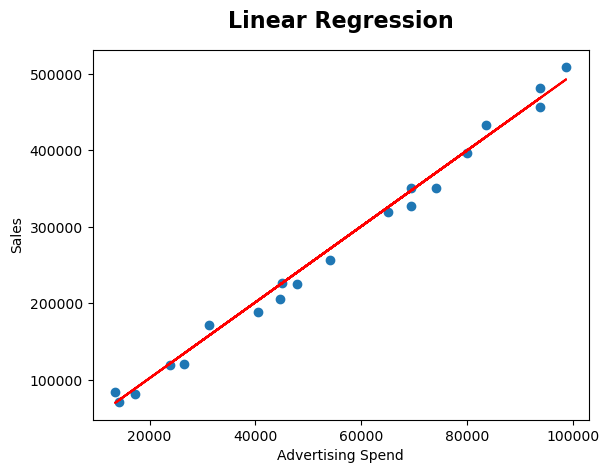

In [46]:
plt.scatter(X_test, y_test)
plt.plot(X_test, predictions, color = "red")
plt.xlabel("Advertising Spend")
plt.ylabel("Sales")
plt.title("Linear Regression", fontsize = 16, fontweight = "bold", pad = 16)
plt.show()